# LangGraph

### Env Keys

In [1]:
%load_ext dotenv
%dotenv

### Imports

In [2]:
from langgraph.graph import START, END, StateGraph, add_messages, MessagesState
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, BaseMessage, RemoveMessage, SystemMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence
from typing import Literal, Annotated
from langgraph.checkpoint.memory import InMemorySaver
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

### Defining Nodes

In [3]:
class State(MessagesState):
    summary: str

In [4]:
chat = ChatOpenAI(model="gpt-4",
                  temperature=0.7,
                  max_tokens=2048
                 )   

In [5]:
def ask_question(state: State) -> State:
    question = "What is your question?"
    
    return State(messages = [AIMessage(question), HumanMessage(input())])


def chatbot(state: State) -> State:
    for message in state["messages"]:
        message.pretty_print()
    
    system_message = f"""
    Here's a quick summary of what's been discussed so far:
    {state.get("summary", "")}

    Keep this in mind as you answer the user's question.
    """

    response = chat.invoke([SystemMessage(content=system_message)] + state["messages"])
    response.pretty_print()

    return State(messages = [response])


def ask_additional_question(state: State) -> State:
    
    question = "Do you have another question? (yes/no)"
    print(question)
    
    return State(messages = [AIMessage(question), HumanMessage(input())])


def routing_function(state: State) -> Literal["summarize_and_trim_messages", "__end__"]:
    last_message = state["messages"][-1].content.lower()
    
    if last_message == "yes":
        return "summarize_and_trim_messages"
    else:
        return "__end__"


def summarize_and_trim_messages(state: State) -> State:
    new_conversation = ""
    for i in state["messages"]:
        new_conversation += f"{i.type}: {i.content}\n\n"

    summary_instructions = f"""
        Summarize the following conversation in a concise manner, keeping all important details intact.
        Build upon the previous summary rather than repeating it so that the result reflects the most recent
        context and developments.

        Previous Summary:
        {state.get("summary", "")}

        New Conversation:
        {new_conversation}
    """

    print(summary_instructions)

    summary = chat.invoke([HumanMessage(summary_instructions)])

    remove_messages = [RemoveMessage(id = i.id) for i in state["messages"][:]]

    return State(messages = remove_messages, summary = summary.content)

### Define the Graph

In [6]:
# A graph whose notes read and write to a saved state

graph = StateGraph(MessagesState)
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
# graph.add_node("ask_additional_question", ask_additional_question)
graph.add_node("summarize_and_trim_messages", summarize_and_trim_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "summarize_and_trim_messages")
graph.add_edge("summarize_and_trim_messages", END)
#graph.add_conditional_edges(source="ask_additional_question",
#                            path = routing_function,)
#graph.add_edge("summarize_and_trim_messages", "ask_question")

In [7]:
db_path = "conversation_history.db"
con = sqlite3.connect(db_path, check_same_thread = False)
checkpointer = SqliteSaver(con)

In [8]:
compiled_graph = graph.compile(checkpointer=checkpointer) # turns this into a runnable

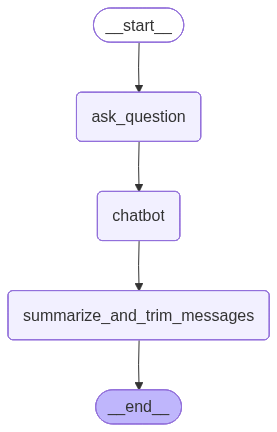

In [9]:
compiled_graph

In [10]:
config1 = {"configurable": {"thread_id": "1"}}
compiled_graph.invoke(State(), config=config1)

================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

Where was he born?
================================== Ai Message ==================================

Frederick II was born in Iesi, Marche, in modern-day Italy on December 26, 1194.

        Summarize the following conversation in a concise manner, keeping all important details intact.
        Build upon the previous summary rather than repeating it so that the result reflects the most recent
        context and developments.

        Previous Summary:
        The AI described Frederick II, a powerful Holy Roman Emperor from the House of Hohenstaufen, whose reign lasted from 1220 to 1250. Known for his intellect, appreciation of arts and sciences, and fluency in several languages, Frederick II earned the nickname "stupor mundi" (wonder of the world). He promoted cultural growth and exchange, and unique

{'messages': []}